In [9]:
# Import packages and modules
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow_decision_forests as tfdf

from sklearn.model_selection import train_test_split

In [10]:
# Check the version of TensorFlow Decision Forests
print("Found TensorFlow Decision Forests v" + tfdf.__version__)

Found TensorFlow Decision Forests v1.12.0


In [11]:
# train/validation = 80/20
dataset = pd.read_csv('dataset/glcm/kernel5-radius5/dataset.csv')
train_data, validation_data = train_test_split(
    dataset, test_size=0.2, random_state=42
)

In [12]:
# Convert the dataset into a TensorFlow dataset.
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    train_data, label="label"
)         
val_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    validation_data, label="label"
)

E0000 00:00:1766163152.187068   19048 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1766163152.189390   19048 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [13]:
import keras

In [14]:
%%time

# Train a Random Forest model.
model = tfdf.keras.RandomForestModel()

# Add evaluation metrics
model.compile(
    metrics=["accuracy"]
)
model.fit(x=train_ds)

# # Train a Gradient Boosted Trees model.
# model = tfdf.keras.GradientBoostedTreesModel(num_trees=1500)
# model.fit(train_ds)

Use /tmp/tmppq8lqldd as temporary training directory
Reading training dataset...
Training dataset read in 0:00:03.009124. Found 89956 examples.
Training model...


I0000 00:00:1766163155.357395   19048 kernel.cc:782] Start Yggdrasil model training
I0000 00:00:1766163155.357442   19048 kernel.cc:783] Collect training examples
I0000 00:00:1766163155.357451   19048 kernel.cc:795] Dataspec guide:
column_guides {
  column_name_pattern: "^__LABEL$"
  type: CATEGORICAL
  categorial {
    min_vocab_frequency: 0
    max_vocab_count: -1
  }
}
default_column_guide {
  categorial {
    max_vocab_count: 2000
  }
  discretized_numerical {
    maximum_num_bins: 255
  }
}
ignore_columns_without_guides: false
detect_numerical_as_discretized_numerical: false

I0000 00:00:1766163155.357734   19048 kernel.cc:401] Number of batches: 90
I0000 00:00:1766163155.357756   19048 kernel.cc:402] Number of examples: 89956
I0000 00:00:1766163155.364940   19048 kernel.cc:802] Training dataset:
Number of records: 89956
Number of columns: 25

Number of columns by type:
	NUMERICAL: 24 (96%)
	CATEGORICAL: 1 (4%)

Columns:

NUMERICAL: 24 (96%)
	0: "Autocorrelation" NUMERICAL mean:15

Model trained in 0:00:13.593123
Compiling model...


I0000 00:00:1766163168.831638   19048 decision_forest.cc:808] Model loaded with 300 root(s), 649310 node(s), and 24 input feature(s).
I0000 00:00:1766163168.834927   19048 abstract_model.cc:1439] Engine "RandomForestOptPred" built
2025-12-19 16:52:48.834983: I tensorflow_decision_forests/tensorflow/ops/inference/kernel.cc:1035] Use fast generic engine


Model compiled.
CPU times: user 1min 58s, sys: 2.11 s, total: 2min
Wall time: 17.4 s


In [15]:
# Evaluate the model
evaluate = model.evaluate(val_ds, return_dict=True)
print()

for name, value in evaluate.items():
    print(f"{name}: {value:.4f}")

23/23 [==============================] - 1s 25ms/step - loss: 0.0000e+00 - accuracy: 0.9719

loss: 0.0000
accuracy: 0.9719


In [16]:
# Model Summary
model.summary()

Model: "random_forest_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
Total params: 1 (1.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 1 (1.00 Byte)
_________________________________________________________________
Type: "RANDOM_FOREST"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (24):
	Autocorrelation
	ClusterProminence
	ClusterShade
	ClusterTendency
	Contrast
	Correlation
	DifferenceAverage
	DifferenceEntropy
	DifferenceVariance
	Id
	Idm
	Idmn
	Idn
	Imc1
	Imc2
	InverseVariance
	JointAverage
	JointEnergy
	JointEntropy
	MCC
	MaximumProbability
	SumAverage
	SumEntropy
	SumSquares

No weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.         "SumAverage"  0.163147 ################
    2.    "Autocorrelation"  0.151721 #############
    3.       "JointAverage"  0.141759 ###########
    4.        "Correlation"  0.130903 #########
    5.               "Imc1"  0.125964

In [17]:
# Model features
model.make_inspector().features()

["Autocorrelation" (1; #0),
 "ClusterProminence" (1; #1),
 "ClusterShade" (1; #2),
 "ClusterTendency" (1; #3),
 "Contrast" (1; #4),
 "Correlation" (1; #5),
 "DifferenceAverage" (1; #6),
 "DifferenceEntropy" (1; #7),
 "DifferenceVariance" (1; #8),
 "Id" (1; #9),
 "Idm" (1; #10),
 "Idmn" (1; #11),
 "Idn" (1; #12),
 "Imc1" (1; #13),
 "Imc2" (1; #14),
 "InverseVariance" (1; #15),
 "JointAverage" (1; #16),
 "JointEnergy" (1; #17),
 "JointEntropy" (1; #18),
 "MCC" (1; #19),
 "MaximumProbability" (1; #20),
 "SumAverage" (1; #21),
 "SumEntropy" (1; #22),
 "SumSquares" (1; #23)]

In [18]:
# Feature importance
model.make_inspector().variable_importances()

{'INV_MEAN_MIN_DEPTH': [("SumAverage" (1; #21), 0.1631474992413709),
  ("Autocorrelation" (1; #0), 0.1517214884079221),
  ("JointAverage" (1; #16), 0.14175897259481965),
  ("Correlation" (1; #5), 0.13090293012099724),
  ("Imc1" (1; #13), 0.12596377311025989),
  ("MCC" (1; #19), 0.10664954621949439),
  ("InverseVariance" (1; #15), 0.10370404634149026),
  ("DifferenceVariance" (1; #8), 0.10310871012031346),
  ("Idn" (1; #12), 0.09385180532795281),
  ("Contrast" (1; #4), 0.09344586628195761),
  ("DifferenceEntropy" (1; #7), 0.09317149427995867),
  ("Idmn" (1; #11), 0.09205751743391641),
  ("Imc2" (1; #14), 0.09180919822113295),
  ("SumEntropy" (1; #22), 0.08875119814605889),
  ("DifferenceAverage" (1; #6), 0.08833488935980684),
  ("MaximumProbability" (1; #20), 0.08623497223226995),
  ("JointEnergy" (1; #17), 0.0851716339312061),
  ("ClusterShade" (1; #2), 0.08461911556283883),
  ("Idm" (1; #10), 0.08396029776280194),
  ("Id" (1; #9), 0.08336134409741999),
  ("ClusterProminence" (1; #1), 

In [19]:
# Model self evaluation
model.make_inspector().evaluation()

Evaluation(num_examples=89956, accuracy=0.9726310640757704, loss=0.10670850914003302, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)

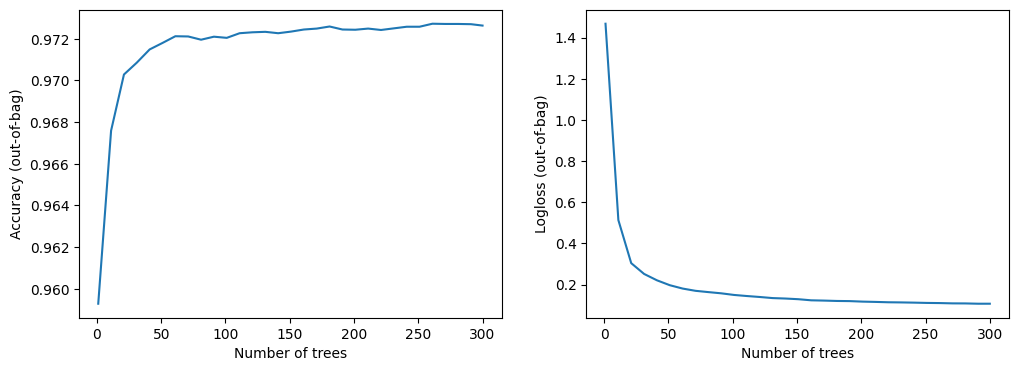

In [20]:
logs = model.make_inspector().training_logs()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot([log.num_trees for log in logs], [log.evaluation.accuracy for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Accuracy (out-of-bag)")
plt.subplot(1, 2, 2)
plt.plot([log.num_trees for log in logs], [log.evaluation.loss for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Logloss (out-of-bag)")
plt.show()

Calculate the score of our hold-out validation dataset

In [21]:
predictions = model.predict(val_ds)
y_true      = validation_data["label"]

from sklearn.metrics import roc_auc_score
ROC_AUC = roc_auc_score(y_true, predictions)
print("The ROC AUC score is %.5f" % ROC_AUC )

23/23 [==============================] - 1s 26ms/step
The ROC AUC score is 0.97817


In [22]:
# Compute binary classification metrics with sklearn
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss,
    brier_score_loss,
)

# Get predictions (probabilities or class labels)
preds = model.predict(val_ds)
# If model outputs probabilities, convert to labels by threshold 0.5
if preds.ndim == 2:
    # For TFDF classification, preds may be class probabilities with shape (N, 2)
    if preds.shape[1] == 2:
        pos_probs = preds[:, 1]
    else:
        # If single-probability column (positive class)
        pos_probs = preds[:, -1]
    y_pred = (pos_probs >= 0.5).astype(int)
else:
    # Already class labels
    y_pred = preds.astype(int)
    pos_probs = None

# Ground truth labels (must be 0/1 integers)
y_true = validation_data["label"].astype(int).to_numpy()

# Core metrics
metrics = {}
metrics["accuracy"] = accuracy_score(y_true, y_pred)
metrics["precision"] = precision_score(y_true, y_pred, zero_division=0)
metrics["recall"] = recall_score(y_true, y_pred, zero_division=0)
metrics["f1"] = f1_score(y_true, y_pred, zero_division=0)
metrics["mcc"] = matthews_corrcoef(y_true, y_pred)

# Probabilistic metrics (only if we have probabilities)
if pos_probs is not None:
    metrics["roc_auc"] = roc_auc_score(y_true, pos_probs)
    metrics["pr_auc"] = average_precision_score(y_true, pos_probs)
    metrics["log_loss"] = log_loss(y_true, pos_probs, labels=[0,1])
    metrics["brier_score"] = brier_score_loss(y_true, pos_probs)

# Confusion matrix and detailed report
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
report = classification_report(y_true, y_pred, digits=4)

print("Sklearn binary metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", report)

23/23 [==============================] - 1s 25ms/step
Sklearn binary metrics:
accuracy: 0.9719
precision: 0.8998
recall: 0.6905
f1: 0.7813
mcc: 0.7743
roc_auc: 0.9782
pr_auc: 0.8815
log_loss: 0.0842
brier_score: 0.0213

Confusion matrix:
 [[20726   126]
 [  507  1131]]

Classification report:
               precision    recall  f1-score   support

           0     0.9761    0.9940    0.9850     20852
           1     0.8998    0.6905    0.7813      1638

    accuracy                         0.9719     22490
   macro avg     0.9379    0.8422    0.8832     22490
weighted avg     0.9706    0.9719    0.9701     22490

